# Synthetic Dataset Generator
## MSc Data Science Thesis — Autonomous Task Planner
**Author:** Zain Ali | **Institution:** Berlin | **Component:** Phase 1 of 5

---

This notebook generates the synthetic task scheduling dataset used to train and evaluate the RL scheduling agent.
It produces **1,000 task scenarios** split into an **800-scenario training set** and a **200-scenario test set**,
along with exploratory data analysis (EDA) charts for validation and thesis documentation.

### What this notebook covers
1. Library imports and configuration
2. Task and scenario generation logic
3. Disruption event generation
4. Dataset generation (1,000 scenarios)
5. Train/test split and saving to disk
6. Exploratory data analysis and visualizations


## 1. Imports and Configuration

In [1]:
import json
import random
import uuid
import csv
import os
from datetime import datetime, timedelta
from copy import deepcopy

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED   = 42
N_SCENARIOS   = 1000
TRAIN_RATIO   = 0.8
OUTPUT_DIR    = "data"

random.seed(RANDOM_SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})
PALETTE = ["#1D9E75", "#534AB7", "#BA7517", "#2E75B6", "#D85A30"]

print("All imports loaded successfully.")
print(f"Output directory: '{OUTPUT_DIR}/'")
print(f"Random seed: {RANDOM_SEED}")


All imports loaded successfully.
Output directory: 'data/'
Random seed: 42


## 2. Task Name Templates

To simulate realistic productivity task lists, task names are generated from templates
combined with domain-specific vocabulary. This produces varied, human-readable task names
without requiring real user data.


In [2]:
TASK_TEMPLATES = [
    "Write {doc} report",         "Review {doc} document",      "Prepare {doc} presentation",
    "Attend {meeting} meeting",   "Send {doc} email",           "Analyze {data} data",
    "Fix {issue} bug",            "Update {doc} documentation", "Complete {doc} draft",
    "Research {topic}",           "Schedule {meeting} call",    "Finalize {doc} proposal",
    "Submit {doc} form",          "Respond to {topic} feedback","Plan {topic} strategy",
    "Code {feature} module",      "Test {feature} feature",     "Deploy {feature} update",
    "Review {topic} pull request","Create {topic} dashboard",
]

DOC_WORDS     = ["quarterly", "project", "client", "budget", "technical", "annual", "summary"]
MEETING_WORDS = ["team", "client", "sprint", "board", "stakeholder", "1:1", "sync"]
DATA_WORDS    = ["sales", "user", "performance", "market", "financial", "traffic"]
ISSUE_WORDS   = ["critical", "login", "UI", "API", "database", "auth", "cache"]
TOPIC_WORDS   = ["product", "marketing", "security", "roadmap", "pricing", "onboarding"]
FEATURE_WORDS = ["search", "payment", "notification", "export", "analytics", "settings"]

def random_task_name():
    template = random.choice(TASK_TEMPLATES)
    return template.format(
        doc     = random.choice(DOC_WORDS),
        meeting = random.choice(MEETING_WORDS),
        data    = random.choice(DATA_WORDS),
        issue   = random.choice(ISSUE_WORDS),
        topic   = random.choice(TOPIC_WORDS),
        feature = random.choice(FEATURE_WORDS),
    )

# Preview 10 sample task names
print("Sample task names:")
for i in range(10):
    print(f"  {i+1:>2}. {random_task_name()}")


Sample task names:
   1. Attend 1:1 meeting
   2. Attend 1:1 meeting
   3. Review quarterly document
   4. Write technical report
   5. Respond to product feedback
   6. Respond to security feedback
   7. Prepare budget presentation
   8. Complete summary draft
   9. Submit quarterly form
  10. Finalize technical proposal


## 3. Scenario Complexity Configuration

Scenarios are divided into three complexity levels based on the number of tasks.
Each level is equally weighted to ensure balanced representation across the dataset.

| Complexity | Task count | Weight |
|------------|-----------|--------|
| Low        | 5–8       | 33%    |
| Medium     | 9–14      | 34%    |
| High       | 15–20     | 33%    |


In [3]:
COMPLEXITY_CONFIGS = {
    "low":    {"task_range": (5, 8),   "weight": 0.33},
    "medium": {"task_range": (9, 14),  "weight": 0.34},
    "high":   {"task_range": (15, 20), "weight": 0.33},
}

# Disruption type distribution (matches real-world task interruption patterns)
DISRUPTION_TYPES = {
    "urgent_insertion":  0.30,   # A new high-priority task arrives mid-day
    "deadline_shift":    0.40,   # An existing task deadline moves ±2 hours
    "task_cancellation": 0.30,   # An existing task is cancelled
}

print("Complexity config loaded.")
print("Disruption type distribution:")
for dtype, weight in DISRUPTION_TYPES.items():
    print(f"  {dtype:<25} {weight*100:.0f}%")


Complexity config loaded.
Disruption type distribution:
  urgent_insertion          30%
  deadline_shift            40%
  task_cancellation         30%


## 4. Task Generation Logic

Each task in a scenario has the following attributes:

| Attribute      | Description                                      | Range / Values         |
|----------------|--------------------------------------------------|------------------------|
| `id`           | Unique task identifier within the scenario       | T000, T001, ...        |
| `name`         | Human-readable task description                  | Generated from template|
| `deadline`     | ISO 8601 timestamp for task completion           | Within working day     |
| `deadline_min` | Minutes from workday start (internal use)        | 0–600                  |
| `duration_min` | Estimated time to complete the task (minutes)    | 15, 30, 45, ... 240    |
| `priority`     | Importance score                                 | 1 (low) – 5 (high)     |
| `dependencies` | List of task IDs that must complete first        | DAG — no cycles        |
| `status`       | Current task state                               | pending                |

The working day is simulated as **08:00–18:00 (600 minutes)**.


In [4]:
def generate_task(task_index, workday_start_min, workday_duration_min):
    task_id  = f"T{task_index:03d}"
    name     = random_task_name()
    duration = random.choice([15, 20, 30, 45, 60, 90, 120, 150, 180, 240])
    # Priority: weighted toward medium (3), less common extremes
    priority = random.choices([1, 2, 3, 4, 5], weights=[0.10, 0.20, 0.35, 0.25, 0.10])[0]

    # Deadline must be at least 'duration' minutes from start and within the workday
    earliest = workday_start_min + duration
    latest   = workday_start_min + workday_duration_min
    deadline_offset = random.randint(earliest, latest)

    base_date    = datetime(2025, 1, 6, 8, 0, 0)   # Simulated Monday 08:00
    deadline_dt  = base_date + timedelta(minutes=deadline_offset)

    return {
        "id":           task_id,
        "name":         name,
        "deadline":     deadline_dt.strftime("%Y-%m-%dT%H:%M:%S"),
        "deadline_min": deadline_offset,
        "duration_min": duration,
        "priority":     priority,
        "dependencies": [],
        "status":       "pending",
    }


def add_dependencies(tasks):
    """Add dependency edges forming a DAG (no cycles).
    ~25% of tasks depend on one earlier task."""
    for i in range(1, len(tasks)):
        if random.random() < 0.25:
            dep_idx = random.randint(0, i - 1)
            tasks[i]["dependencies"].append(tasks[dep_idx]["id"])
    return tasks


# ── Preview: generate and display one sample task ──────────────────────────
sample_task = generate_task(0, 0, 600)
print("Sample task structure:")
print(json.dumps(sample_task, indent=2))


Sample task structure:
{
  "id": "T000",
  "name": "Update summary documentation",
  "deadline": "2025-01-06T15:25:00",
  "deadline_min": 445,
  "duration_min": 120,
  "priority": 2,
  "dependencies": [],
  "status": "pending"
}


## 5. Disruption Event Generation

Disruptions simulate real-world scheduling interruptions.
Each scenario contains **1–3 disruption events** randomly selected from three types.

These are critical for evaluating the RL agent's ability to **adapt dynamically**,
which is the core research contribution of this thesis.


In [5]:
def generate_disruptions(tasks, n_disruptions):
    disruptions = []
    # Only cancel tasks that nothing else depends on
    cancellable = [t for t in tasks if not t["dependencies"]]

    for _ in range(n_disruptions):
        dtype = random.choices(
            list(DISRUPTION_TYPES.keys()),
            weights=list(DISRUPTION_TYPES.values())
        )[0]

        if dtype == "urgent_insertion":
            base_date    = datetime(2025, 1, 6, 8, 0, 0)
            arrival_min  = random.randint(60, 480)
            deadline_min = arrival_min + random.randint(60, 180)
            deadline_dt  = base_date + timedelta(minutes=deadline_min)
            disruptions.append({
                "type":        "urgent_insertion",
                "arrival_min": arrival_min,
                "task": {
                    "id":           f"URGENT_{uuid.uuid4().hex[:6].upper()}",
                    "name":         f"URGENT: {random_task_name()}",
                    "deadline":     deadline_dt.strftime("%Y-%m-%dT%H:%M:%S"),
                    "deadline_min": deadline_min,
                    "duration_min": random.choice([15, 30, 45, 60]),
                    "priority":     5,
                    "dependencies": [],
                    "status":       "pending",
                }
            })

        elif dtype == "deadline_shift" and tasks:
            target   = random.choice(tasks)
            shift    = random.choice([-120, -90, -60, 60, 90, 120])
            base_date = datetime(2025, 1, 6, 8, 0, 0)
            new_dl   = max(target["duration_min"], target["deadline_min"] + shift)
            new_dl   = min(new_dl, 600)
            new_dt   = (base_date + timedelta(minutes=new_dl)).strftime("%Y-%m-%dT%H:%M:%S")
            disruptions.append({
                "type":             "deadline_shift",
                "target_task_id":   target["id"],
                "shift_minutes":    shift,
                "new_deadline":     new_dt,
                "new_deadline_min": new_dl,
            })

        elif dtype == "task_cancellation" and cancellable:
            target = random.choice(cancellable)
            disruptions.append({
                "type":           "task_cancellation",
                "target_task_id": target["id"],
            })

    return disruptions


print("Disruption generator defined.")
print("Disruption types:", list(DISRUPTION_TYPES.keys()))


Disruption generator defined.
Disruption types: ['urgent_insertion', 'deadline_shift', 'task_cancellation']


## 6. Full Scenario Generation

A **scenario** is the complete unit of data consumed by the RL agent.
It bundles a task list, metadata, and disruption events into a single JSON object.

The `feasible` flag indicates whether all tasks *could* fit within the 600-minute workday
if scheduled perfectly. Only ~20% of scenarios are feasible — this is intentional.
The agent's job is to **optimise under pressure**, not in easy conditions.


In [6]:
def complexity_label(n_tasks):
    if n_tasks <= 8:  return "low"
    if n_tasks <= 14: return "medium"
    return "high"


def generate_scenario(scenario_id):
    complexity  = random.choices(
        list(COMPLEXITY_CONFIGS.keys()),
        weights=[c["weight"] for c in COMPLEXITY_CONFIGS.values()]
    )[0]
    n_tasks = random.randint(*COMPLEXITY_CONFIGS[complexity]["task_range"])

    WORKDAY_START    = 0
    WORKDAY_DURATION = 600

    tasks = [generate_task(i, WORKDAY_START, WORKDAY_DURATION) for i in range(n_tasks)]
    tasks = add_dependencies(tasks)
    tasks.sort(key=lambda t: t["deadline_min"])   # Initial ordering by deadline

    n_disruptions = random.randint(1, 3)
    disruptions   = generate_disruptions(tasks, n_disruptions)

    total_duration = sum(t["duration_min"] for t in tasks)
    feasible       = total_duration <= WORKDAY_DURATION

    return {
        "scenario_id":        scenario_id,
        "complexity":         complexity_label(n_tasks),
        "n_tasks":            n_tasks,
        "n_disruptions":      len(disruptions),
        "workday_minutes":    WORKDAY_DURATION,
        "total_duration_min": total_duration,
        "feasible":           feasible,
        "tasks":              tasks,
        "disruptions":        disruptions,
    }


# ── Preview one scenario ──────────────────────────────────────────────────────
sample = generate_scenario("SCN_PREVIEW")
print(f"Scenario ID     : {sample['scenario_id']}")
print(f"Complexity      : {sample['complexity']}")
print(f"Tasks           : {sample['n_tasks']}")
print(f"Disruptions     : {sample['n_disruptions']}")
print(f"Total duration  : {sample['total_duration_min']} min")
print(f"Workday         : {sample['workday_minutes']} min")
print(f"Feasible        : {sample['feasible']}")
print()
print("First task in scenario:")
print(json.dumps(sample["tasks"][0], indent=2))
print()
print("First disruption:")
print(json.dumps(sample["disruptions"][0], indent=2))


Scenario ID     : SCN_PREVIEW
Complexity      : high
Tasks           : 16
Disruptions     : 1
Total duration  : 1605 min
Workday         : 600 min
Feasible        : False

First task in scenario:
{
  "id": "T014",
  "name": "Update technical documentation",
  "deadline": "2025-01-06T08:47:00",
  "deadline_min": 47,
  "duration_min": 15,
  "priority": 2,
  "dependencies": [],
  "status": "pending"
}

First disruption:
{
  "type": "deadline_shift",
  "target_task_id": "T009",
  "shift_minutes": -120,
  "new_deadline": "2025-01-06T12:00:00",
  "new_deadline_min": 240
}


## 7. Generate the Full Dataset (1,000 Scenarios)

Running this cell generates all 1,000 scenarios and saves them to disk.
This takes approximately 2–5 seconds on a standard laptop.

> **Note:** `random.seed(42)` is set at the top of the notebook to ensure
> the dataset is **fully reproducible** — running this cell again produces
> the identical dataset.


In [7]:
random.seed(RANDOM_SEED)   # Reset seed for full reproducibility

print(f"Generating {N_SCENARIOS} scenarios...")
all_scenarios = []
for i in range(1, N_SCENARIOS + 1):
    scenario = generate_scenario(f"SCN_{i:04d}")
    all_scenarios.append(scenario)
    if i % 200 == 0:
        print(f"  {i}/{N_SCENARIOS} scenarios generated")

print(f"\nDone. Total scenarios: {len(all_scenarios)}")


Generating 1000 scenarios...
  200/1000 scenarios generated
  400/1000 scenarios generated
  600/1000 scenarios generated


  800/1000 scenarios generated
  1000/1000 scenarios generated

Done. Total scenarios: 1000


## 8. Train / Test Split and Save to Disk

The dataset is split **80% train / 20% test**:
- `train_scenarios.json` — **800 scenarios** used to train the RL agent
- `test_scenarios.json`  — **200 scenarios** locked away for final evaluation

> ⚠️ **Critical rule:** The RL agent must **never** see the test set during training.
> These 200 scenarios are used only once — during final comparative evaluation
> against the FIFO and priority queue baselines.


In [8]:
def split_and_save(scenarios, output_dir, train_ratio=0.8):
    shuffled = scenarios.copy()
    random.shuffle(shuffled)
    split    = int(len(shuffled) * train_ratio)
    train    = shuffled[:split]
    test     = shuffled[split:]

    # Save all files
    files = {
        "scenarios.json":       scenarios,
        "train_scenarios.json": train,
        "test_scenarios.json":  test,
    }
    for fname, data in files.items():
        path = os.path.join(output_dir, fname)
        with open(path, "w") as f:
            json.dump(data, f, indent=2)
        print(f"  Saved {len(data):>4} scenarios → {path}")

    # Save summary CSV
    csv_path = os.path.join(output_dir, "dataset_summary.csv")
    fields   = ["scenario_id","complexity","n_tasks","n_disruptions",
                 "total_duration_min","feasible","workday_minutes"]
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for s in scenarios:
            writer.writerow({k: s[k] for k in fields})
    print(f"  Saved summary CSV  → {csv_path}")

    return train, test


train_scenarios, test_scenarios = split_and_save(all_scenarios, OUTPUT_DIR)
print(f"\nTrain set : {len(train_scenarios)} scenarios")
print(f"Test set  : {len(test_scenarios)} scenarios")


  Saved 1000 scenarios → data/scenarios.json
  Saved  800 scenarios → data/train_scenarios.json
  Saved  200 scenarios → data/test_scenarios.json
  Saved summary CSV  → data/dataset_summary.csv

Train set : 800 scenarios
Test set  : 200 scenarios


## 9. Exploratory Data Analysis

The following charts validate the dataset and provide figures for the thesis
**Dataset** section (Chapter 4.4). Each chart can be saved and embedded directly
into the thesis document.


In [9]:
# Load summary CSV for EDA
df = pd.read_csv(os.path.join(OUTPUT_DIR, "dataset_summary.csv"))

print("Dataset shape:", df.shape)
print()
print(df.describe().round(2))


Dataset shape: (1000, 7)

       n_tasks  n_disruptions  total_duration_min  workday_minutes
count  1000.00        1000.00             1000.00           1000.0
mean     11.87           2.01             1124.85            600.0
std       4.79           0.82              516.43              0.0
min       5.00           1.00              135.00            600.0
25%       8.00           1.00              690.00            600.0
50%      11.00           2.00             1085.00            600.0
75%      16.00           3.00             1505.00            600.0
max      20.00           3.00             2595.00            600.0


### 9.1 Complexity Distribution

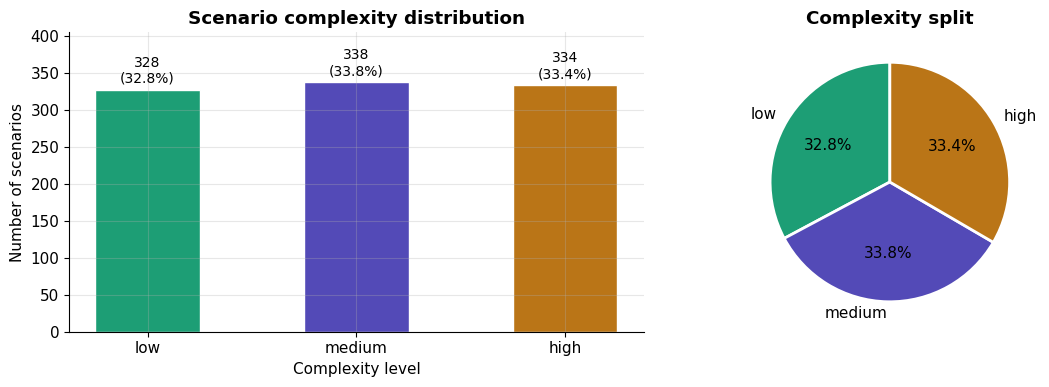

Figure saved: fig1_complexity_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
complexity_counts = df["complexity"].value_counts().reindex(["low","medium","high"])
bars = axes[0].bar(complexity_counts.index, complexity_counts.values,
                   color=PALETTE[:3], width=0.5, edgecolor="white")
axes[0].set_title("Scenario complexity distribution", fontweight="bold")
axes[0].set_xlabel("Complexity level")
axes[0].set_ylabel("Number of scenarios")
for bar, val in zip(bars, complexity_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{val}\n({val/N_SCENARIOS*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_ylim(0, max(complexity_counts.values) * 1.2)

# Pie chart
axes[1].pie(complexity_counts.values, labels=complexity_counts.index,
            colors=PALETTE[:3], autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Complexity split", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_complexity_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig1_complexity_distribution.png")


### 9.2 Task Count Distribution

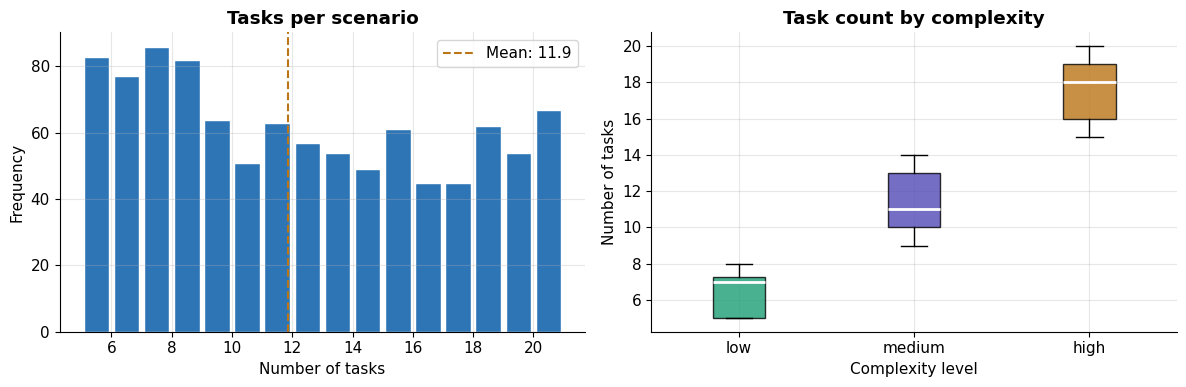

Figure saved: fig2_task_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of tasks per scenario
axes[0].hist(df["n_tasks"], bins=range(5, 22), color=PALETTE[3],
             edgecolor="white", rwidth=0.85)
axes[0].set_title("Tasks per scenario", fontweight="bold")
axes[0].set_xlabel("Number of tasks")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["n_tasks"].mean(), color=PALETTE[2], linestyle="--",
                linewidth=1.5, label=f"Mean: {df['n_tasks'].mean():.1f}")
axes[0].legend()

# Box plot by complexity
complexity_order = ["low","medium","high"]
data_by_complexity = [df[df["complexity"]==c]["n_tasks"].values for c in complexity_order]
bp = axes[1].boxplot(data_by_complexity, labels=complexity_order,
                     patch_artist=True, medianprops={"color":"white","linewidth":2})
for patch, color in zip(bp["boxes"], PALETTE[:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title("Task count by complexity", fontweight="bold")
axes[1].set_xlabel("Complexity level")
axes[1].set_ylabel("Number of tasks")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_task_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig2_task_distribution.png")


### 9.3 Disruption Analysis

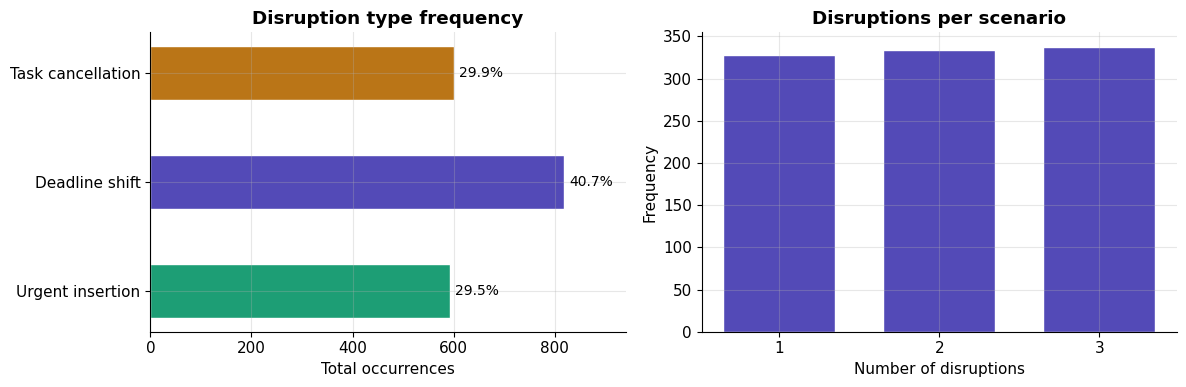

Figure saved: fig3_disruption_analysis.png


In [12]:
# Count disruption types across all scenarios
disruption_counts = {"urgent_insertion": 0, "deadline_shift": 0, "task_cancellation": 0}
with open(os.path.join(OUTPUT_DIR, "scenarios.json")) as f:
    all_data = json.load(f)
for s in all_data:
    for d in s["disruptions"]:
        disruption_counts[d["type"]] += 1

total_d = sum(disruption_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
labels      = ["Urgent insertion", "Deadline shift", "Task cancellation"]
short_lbls  = ["urgent_insertion","deadline_shift","task_cancellation"]
counts      = [disruption_counts[k] for k in short_lbls]
pcts        = [c/total_d*100 for c in counts]

bars = axes[0].barh(labels, counts, color=PALETTE[:3], edgecolor="white", height=0.5)
axes[0].set_title("Disruption type frequency", fontweight="bold")
axes[0].set_xlabel("Total occurrences")
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f"{pct:.1f}%", va="center", fontsize=10)
axes[0].set_xlim(0, max(counts) * 1.15)

# Disruptions per scenario
axes[1].hist(df["n_disruptions"], bins=[0.5,1.5,2.5,3.5],
             color=PALETTE[1], edgecolor="white", rwidth=0.7)
axes[1].set_title("Disruptions per scenario", fontweight="bold")
axes[1].set_xlabel("Number of disruptions")
axes[1].set_ylabel("Frequency")
axes[1].set_xticks([1,2,3])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_disruption_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig3_disruption_analysis.png")


### 9.4 Feasibility Analysis

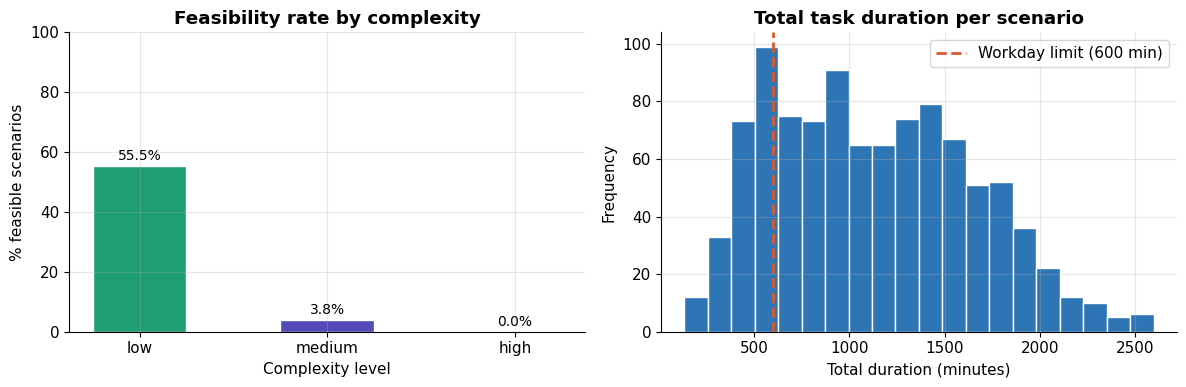

Figure saved: fig4_feasibility_analysis.png
Overall feasibility rate: 19.5%
(~80.5% of scenarios require the agent to make trade-offs)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Feasibility by complexity
feasibility = df.groupby("complexity")["feasible"].mean().reindex(["low","medium","high"]) * 100
bars = axes[0].bar(feasibility.index, feasibility.values,
                   color=PALETTE[:3], width=0.5, edgecolor="white")
axes[0].set_title("Feasibility rate by complexity", fontweight="bold")
axes[0].set_xlabel("Complexity level")
axes[0].set_ylabel("% feasible scenarios")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, feasibility.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

# Total duration distribution
axes[1].hist(df["total_duration_min"], bins=20,
             color=PALETTE[3], edgecolor="white")
axes[1].axvline(600, color=PALETTE[4], linestyle="--", linewidth=2,
                label="Workday limit (600 min)")
axes[1].set_title("Total task duration per scenario", fontweight="bold")
axes[1].set_xlabel("Total duration (minutes)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig4_feasibility_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
feasible_pct = df["feasible"].mean() * 100
print(f"Figure saved: fig4_feasibility_analysis.png")
print(f"Overall feasibility rate: {feasible_pct:.1f}%")
print(f"(~{100-feasible_pct:.1f}% of scenarios require the agent to make trade-offs)")


### 9.5 Priority Distribution

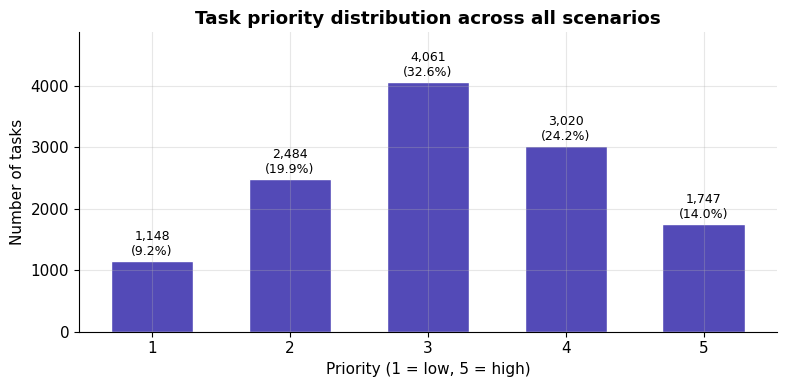

Total tasks across all scenarios: 12,460
Figure saved: fig5_priority_distribution.png


In [14]:
# Extract priority scores across all tasks
all_priorities = []
for s in all_data:
    for t in s["tasks"]:
        all_priorities.append(t["priority"])
    for d in s["disruptions"]:
        if d["type"] == "urgent_insertion":
            all_priorities.append(d["task"]["priority"])

priority_series = pd.Series(all_priorities)
priority_counts = priority_series.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(priority_counts.index, priority_counts.values,
              color=PALETTE[1], edgecolor="white", width=0.6)
ax.set_title("Task priority distribution across all scenarios", fontweight="bold")
ax.set_xlabel("Priority (1 = low, 5 = high)")
ax.set_ylabel("Number of tasks")
ax.set_xticks([1,2,3,4,5])
for bar, val in zip(bars, priority_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}\n({val/len(all_priorities)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(priority_counts.values) * 1.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig5_priority_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Total tasks across all scenarios: {len(all_priorities):,}")
print(f"Figure saved: fig5_priority_distribution.png")


## 10. Dataset Summary

In [15]:
print("=" * 55)
print("  DATASET GENERATION COMPLETE")
print("=" * 55)
print(f"  Total scenarios   : {len(all_scenarios):,}")
print(f"  Training set      : {len(train_scenarios):,} scenarios (80%)")
print(f"  Test set          : {len(test_scenarios):,} scenarios (20%)")
print(f"  Random seed       : {RANDOM_SEED} (fully reproducible)")
print()
print("  Files saved to data/:")
for fname in ["scenarios.json","train_scenarios.json",
              "test_scenarios.json","dataset_summary.csv"]:
    size = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
    print(f"    {fname:<30} {size/1024:.1f} KB")
print()
print("  Figures saved to data/:")
for i in range(1, 6):
    fname = f"fig{i}_*.png"
    print(f"    fig{i}_*.png")
print()
print("  Complexity breakdown:")
for c in ["low","medium","high"]:
    n   = (df["complexity"] == c).sum()
    pct = n / len(df) * 100
    print(f"    {c:<8} {n:>4} scenarios  ({pct:.1f}%)")
print()
print("  Next step → 02_NLP_Pipeline.ipynb")
print("=" * 55)


  DATASET GENERATION COMPLETE
  Total scenarios   : 1,000
  Training set      : 800 scenarios (80%)
  Test set          : 200 scenarios (20%)
  Random seed       : 42 (fully reproducible)

  Files saved to data/:
    scenarios.json                 3748.6 KB
    train_scenarios.json           3005.9 KB
    test_scenarios.json            742.7 KB
    dataset_summary.csv            33.6 KB

  Figures saved to data/:
    fig1_*.png
    fig2_*.png
    fig3_*.png
    fig4_*.png
    fig5_*.png

  Complexity breakdown:
    low       328 scenarios  (32.8%)
    medium    338 scenarios  (33.8%)
    high      334 scenarios  (33.4%)

  Next step → 02_NLP_Pipeline.ipynb
